In [1]:
import json
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont

In [6]:
DATASET_ROOT = Path(r"C:\Users\jerem\Desktop\ARI3129 - Assignment Materials\sir py scripts")
IMAGES_DIR = DATASET_ROOT / "merged_images"
COCO_JSON_PATH = DATASET_ROOT / "COCO.json"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

N_VIS_EXAMPLES = 6

In [8]:
with open(COCO_JSON_PATH, "r", encoding="utf-8") as f:
    coco = json.load(f)


print("Top-level keys:", list(coco.keys()))
print("Images:", len(coco.get("images", [])))
print("Annotations:", len(coco.get("annotations", [])))
print("Categories:", len(coco.get("categories", [])))


Top-level keys: ['info', 'licenses', 'images', 'annotations', 'categories']
Images: 723
Annotations: 806
Categories: 6


In [9]:
images = coco.get("images", [])
annotations = coco.get("annotations", [])
categories = coco.get("categories", [])

cat_id_to_name = {c["id"]: c["name"] for c in categories}

img_id_to_info = {img["id"]: img for img in images}

img_id_to_anns = defaultdict(list)
for ann in annotations:
    img_id_to_anns[ann["image_id"]].append(ann)

print("Category mapping:", list(cat_id_to_name.items())[:5])
print("Images with at least 1 annotation:", sum(1 for k in img_id_to_anns.keys()))

Category mapping: [(1, 'Blind-Spot Mirror (Convex)'), (2, 'No Entry (One Way)'), (3, 'No Through Road (T-Sign)'), (4, 'Pedestrian Crossing'), (5, 'Roundabout Ahead')]
Images with at least 1 annotation: 723


In [10]:
def _get_attr(ann, key):
    attrs = ann.get("attributes", {}) or {}
    val = attrs.get(key, None)
    if val is None:
        return "Unknown"
    if isinstance(val, list) and len(val) > 0:
        return str(val[0])
    return str(val)

rows = []
for ann in annotations:
    bbox = ann.get("bbox", [None, None, None, None])
    x, y, w, h = bbox if len(bbox) == 4 else (None, None, None, None)

    rows.append({
        "ann_id": ann.get("id"),
        "image_id": ann.get("image_id"),
        "category_id": ann.get("category_id"),
        "category_name": cat_id_to_name.get(ann.get("category_id"), "UnknownCategory"),
        "x": x, "y": y, "w": w, "h": h,
        "area": ann.get("area", (w * h if (w is not None and h is not None) else None)),
        "iscrowd": ann.get("iscrowd", 0),

        "view_angle": _get_attr(ann, "view_angle"),
        "mounting": _get_attr(ann, "mounting"),
        "condition": _get_attr(ann, "condition"),
        "sign_shape": _get_attr(ann, "sign_shape"),
    })

ann_df = pd.DataFrame(rows)
ann_df.head()

,ann_id,image_id,category_id,category_name,x,y,w,h,area,iscrowd,view_angle,mounting,condition,sign_shape
0,1,1,1,Blind-Spot Mirror (Convex),1123.106246,1805.466105,764.667990,795.201777,608065.344286,0,Front,Pole-mounted,Good,Circular
1,2,2,1,Blind-Spot Mirror (Convex),641.612400,727.245742,312.803635,578.866482,181071.539708,0,Side,Pole-mounted,Good,Circular
2,3,3,1,Blind-Spot Mirror (Convex),638.106805,964.102035,320.893397,379.319244,121721.040718,0,Back,Pole-mounted,Good,Circular
3,4,4,1,Blind-Spot Mirror (Convex),528.451246,802.662019,532.402394,546.230938,290814.658795,0,Front,Pole-mounted,Weathered,Circular
4,5,5,1,Blind-Spot Mirror (Convex),1306.451749,1441.062041,562.615158,1109.697569,624332.673820,0,Side,Pole-mounted,Weathered,Circular


In [11]:
img_rows = []
missing_files = 0

for img in images:
    file_name = img.get("file_name")
    img_path = IMAGES_DIR / file_name if file_name else None

    if img_path and not img_path.exists():
        missing_files += 1

    img_rows.append({
        "image_id": img.get("id"),
        "file_name": file_name,
        "width": img.get("width"),
        "height": img.get("height"),
        "path": str(img_path) if img_path else None,
    })

img_df = pd.DataFrame(img_rows)

print("Missing image files referenced by JSON:", missing_files)
img_df.head()

Missing image files referenced by JSON: 0


,image_id,file_name,width,height,path
0,1,e6238c33-IMG_5531.jpeg,3024,4032,C:\Users\jerem\Desktop\ARI3129 - Assignment Ma...
1,2,75befbca-IMG_5532.jpeg,1576,2100,C:\Users\jerem\Desktop\ARI3129 - Assignment Ma...
2,3,8054bb80-IMG_5533.jpeg,1576,2100,C:\Users\jerem\Desktop\ARI3129 - Assignment Ma...
3,4,9dfbd54a-IMG_5537.jpeg,1576,2100,C:\Users\jerem\Desktop\ARI3129 - Assignment Ma...
4,5,e3c71733-IMG_5538.jpeg,3024,4032,C:\Users\jerem\Desktop\ARI3129 - Assignment Ma...


In [12]:
n_images = len(img_df)
n_anns = len(ann_df)

anns_per_image = ann_df.groupby("image_id").size()
n_images_with_anns = anns_per_image.shape[0]
avg_anns_per_annotated_image = anns_per_image.mean()
median_anns_per_annotated_image = anns_per_image.median()

print(f"Images total: {n_images}")
print(f"Total Annotations: {n_anns}")
print(f"Images with >=1 annotation: {n_images_with_anns} ({n_images_with_anns/n_images:.1%})")
print(f"Average objects per annotated image: {avg_anns_per_annotated_image:.2f}")
print(f"Median objects per annotated image: {median_anns_per_annotated_image:.2f}")

print("\nCategory counts:")
display(ann_df["category_name"].value_counts())

Images total: 723
Total Annotations: 806
Images with >=1 annotation: 723 (100.0%)
Average objects per annotated image: 1.11
Median objects per annotated image: 1.00

Category counts:


category_name
Pedestrian Crossing           148
Roundabout Ahead              141
Blind-Spot Mirror (Convex)    134
Stop                          133
No Entry (One Way)            130
No Through Road (T-Sign)      120
Name: count, dtype: int64

In [13]:
def _load_font(size=18):
    try:
        return ImageFont.truetype("arial.ttf", size=size)
    except:
        return ImageFont.load_default()

def draw_annotations_on_image(img: Image.Image, anns_for_img, max_labels=6):
    draw = ImageDraw.Draw(img)
    font = _load_font(18)

    for ann in anns_for_img[:max_labels]:
        x, y, w, h = ann["bbox"]
        x2, y2 = x + w, y + h

        # rectangle
        draw.rectangle([x, y, x2, y2], width=4)

        cat_name = cat_id_to_name.get(ann["category_id"], "Unknown")
        attrs = ann.get("attributes", {}) or {}

        def unwrap(v):
            if isinstance(v, list) and len(v) > 0:
                return str(v[0])
            if v is None:
                return "Unknown"
            return str(v)

        view = unwrap(attrs.get("view_angle"))
        mounting = unwrap(attrs.get("mounting"))
        cond = unwrap(attrs.get("condition"))
        shape = unwrap(attrs.get("sign_shape"))

        label = f"{cat_name} | {view}, {mounting}, {cond}, {shape}"

        text_bbox = draw.textbbox((x, y), label, font=font)
        draw.rectangle(text_bbox, fill=None)
        draw.text((x, max(0, y - 22)), label, font=font)

    return img

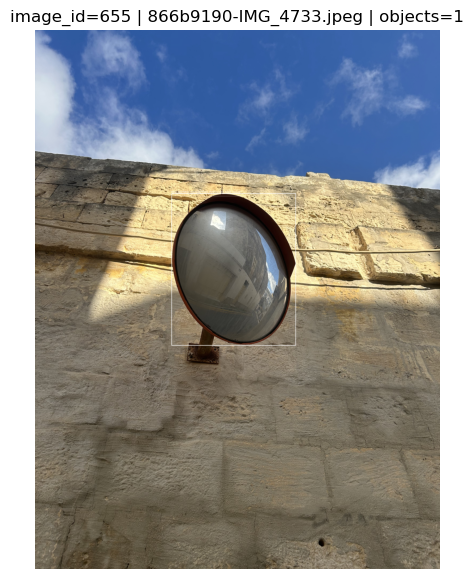

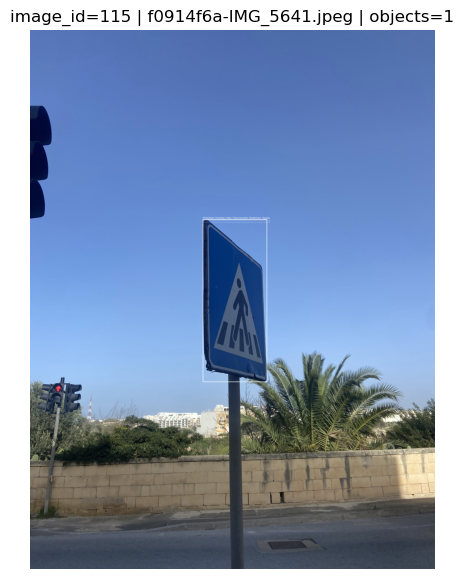

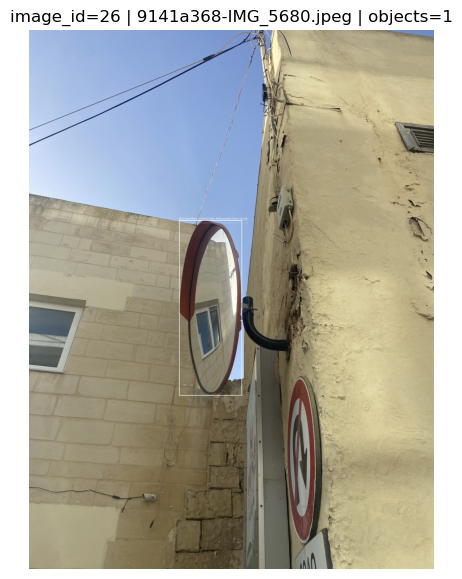

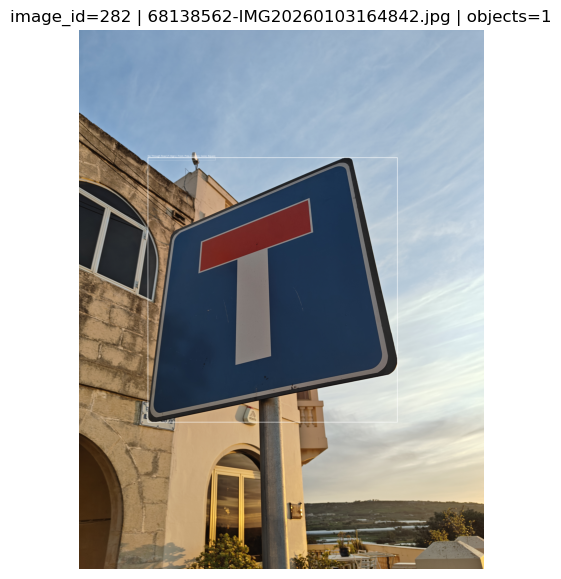

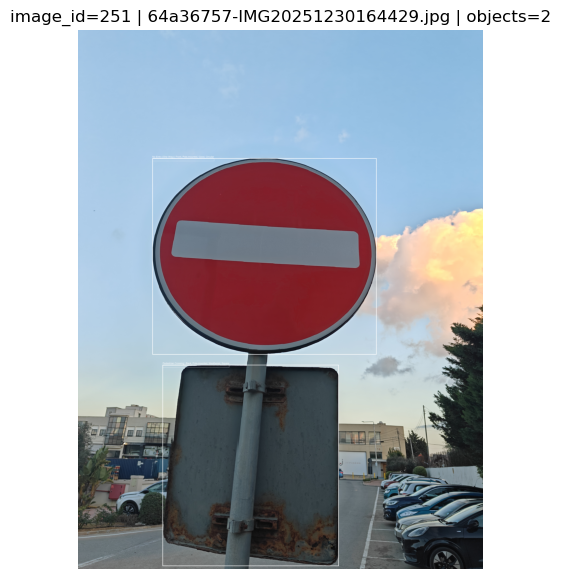

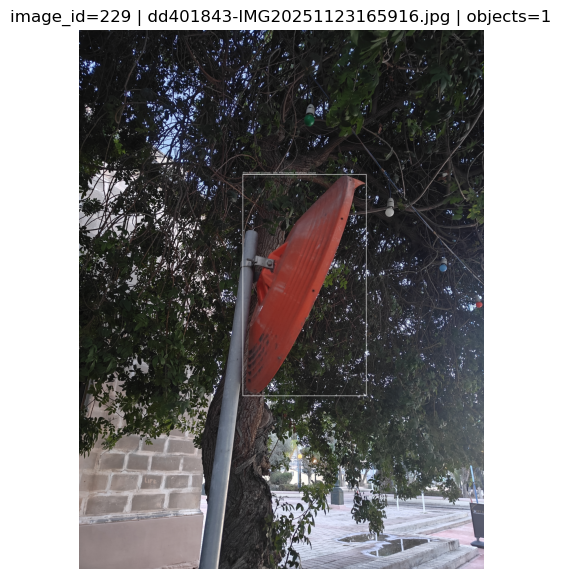

In [14]:
candidate_ids = [img_id for img_id in img_id_to_anns.keys()
                 if (IMAGES_DIR / img_id_to_info[img_id].get("file_name", "")).exists()]

sample_ids = random.sample(candidate_ids, k=min(N_VIS_EXAMPLES, len(candidate_ids)))

for img_id in sample_ids:
    info = img_id_to_info[img_id]
    img_path = IMAGES_DIR / info["file_name"]
    anns_for_img = img_id_to_anns[img_id]

    img = Image.open(img_path).convert("RGB")
    img_annot = draw_annotations_on_image(img.copy(), anns_for_img, max_labels=10)

    plt.figure(figsize=(10, 7))
    plt.imshow(img_annot)
    plt.axis("off")
    plt.title(f"image_id={img_id} | {info['file_name']} | objects={len(anns_for_img)}")
    plt.show()

In [15]:
def plot_value_counts(series: pd.Series, title: str, top_n=None):
    counts = series.value_counts()
    if top_n is not None:
        counts = counts.head(top_n)

    plt.figure(figsize=(10, 5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xticks(rotation=35, ha="right")
    plt.title(title)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def show_distribution_table(series: pd.Series, name: str):
    counts = series.value_counts()
    perc = (counts / counts.sum() * 100).round(2)
    df = pd.DataFrame({f"{name}_count": counts, f"{name}_percent": perc})
    display(df)

,sign_type_count,sign_type_percent
category_name,,
Pedestrian Crossing,148,18.36
Roundabout Ahead,141,17.49
Blind-Spot Mirror (Convex),134,16.63
Stop,133,16.50
No Entry (One Way),130,16.13
No Through Road (T-Sign),120,14.89


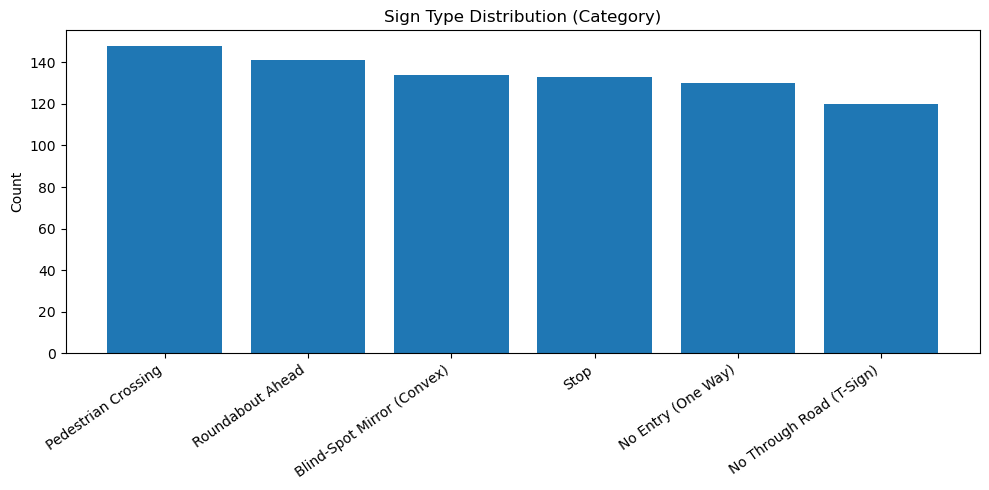

In [16]:
show_distribution_table(ann_df["category_name"], "sign_type")
plot_value_counts(ann_df["category_name"], "Sign Type Distribution (Category)")

,view_angle_count,view_angle_percent
view_angle,,
Back,271,33.62
Front,270,33.50
Side,265,32.88


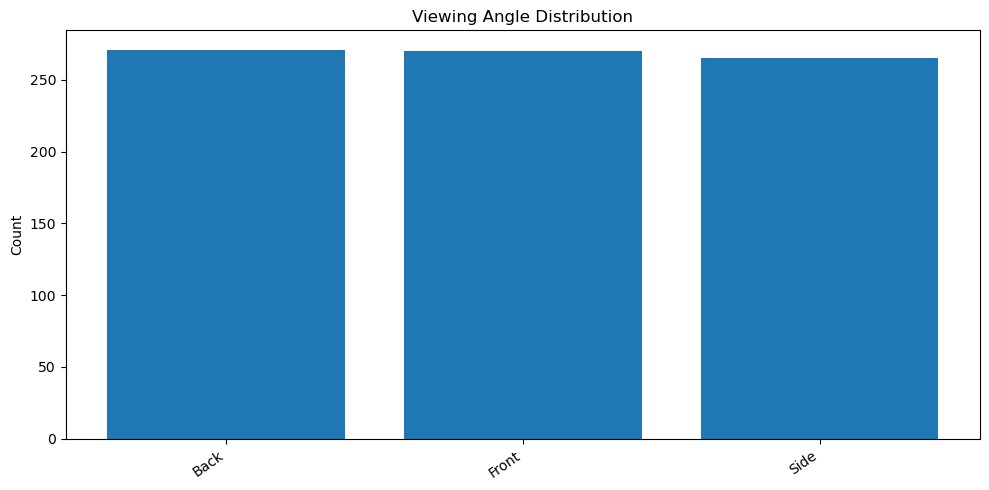

,mounting_count,mounting_percent
mounting,,
Pole-mounted,752,93.3
Wall-mounted,54,6.7


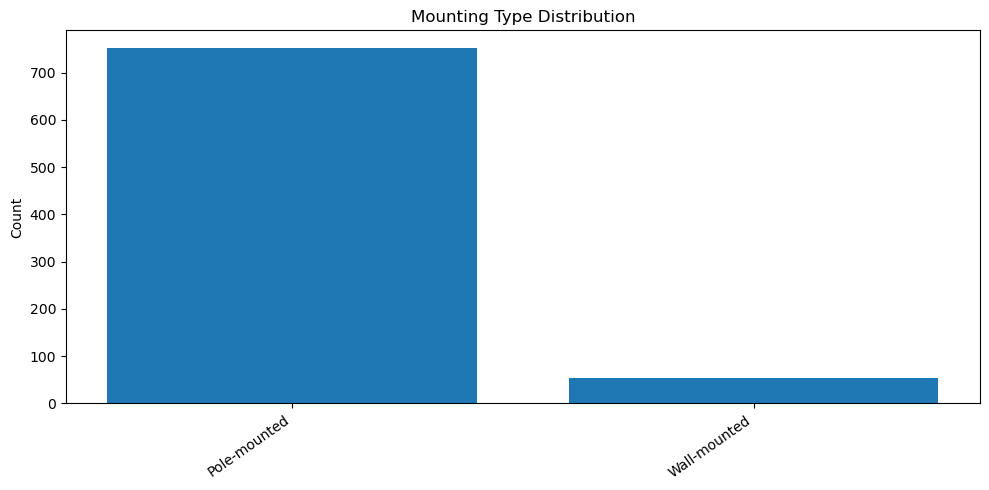

,condition_count,condition_percent
condition,,
Good,653,81.02
Weathered,137,17.00
Heavily Damaged,16,1.99


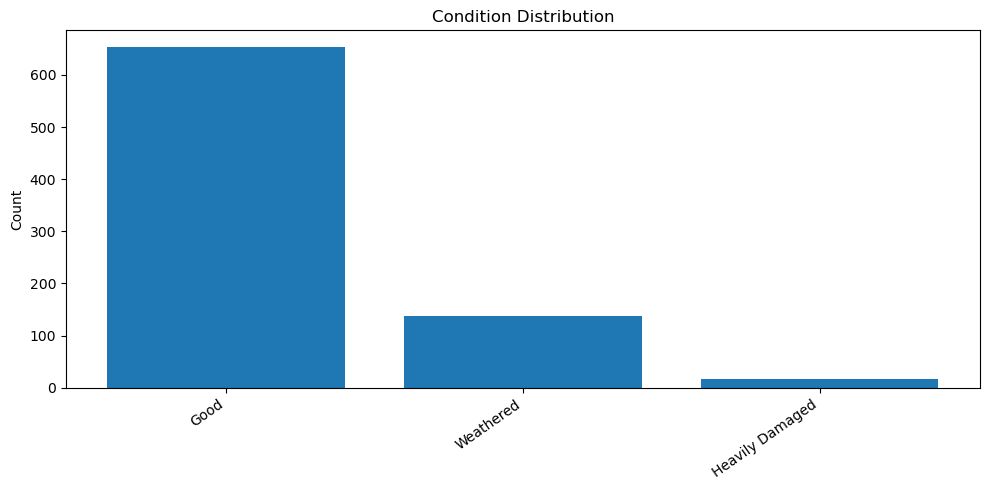

,sign_shape_count,sign_shape_percent
sign_shape,,
Circular,405,50.25
Square,271,33.62
Octagonal,130,16.13


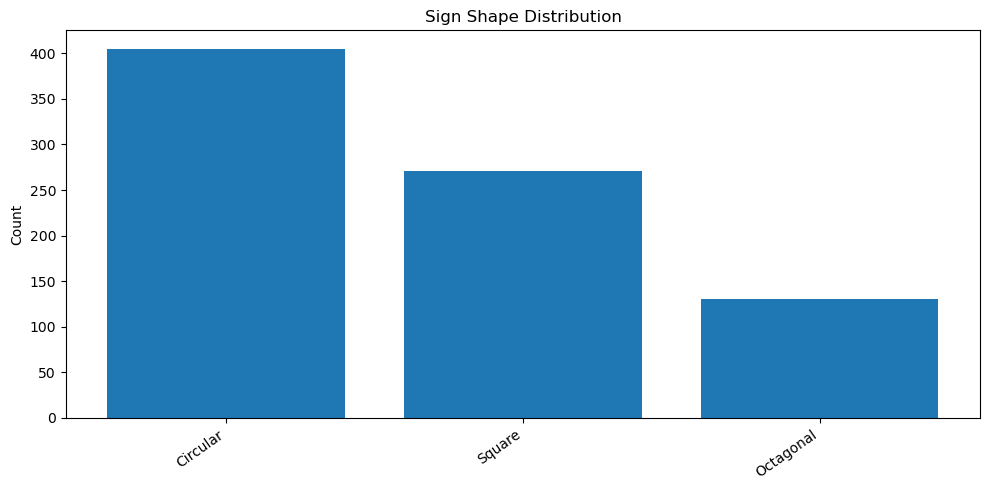

In [17]:
for col, title in [
    ("view_angle", "Viewing Angle Distribution"),
    ("mounting", "Mounting Type Distribution"),
    ("condition", "Condition Distribution"),
    ("sign_shape", "Sign Shape Distribution"),
]:
    show_distribution_table(ann_df[col], col)
    plot_value_counts(ann_df[col], title)

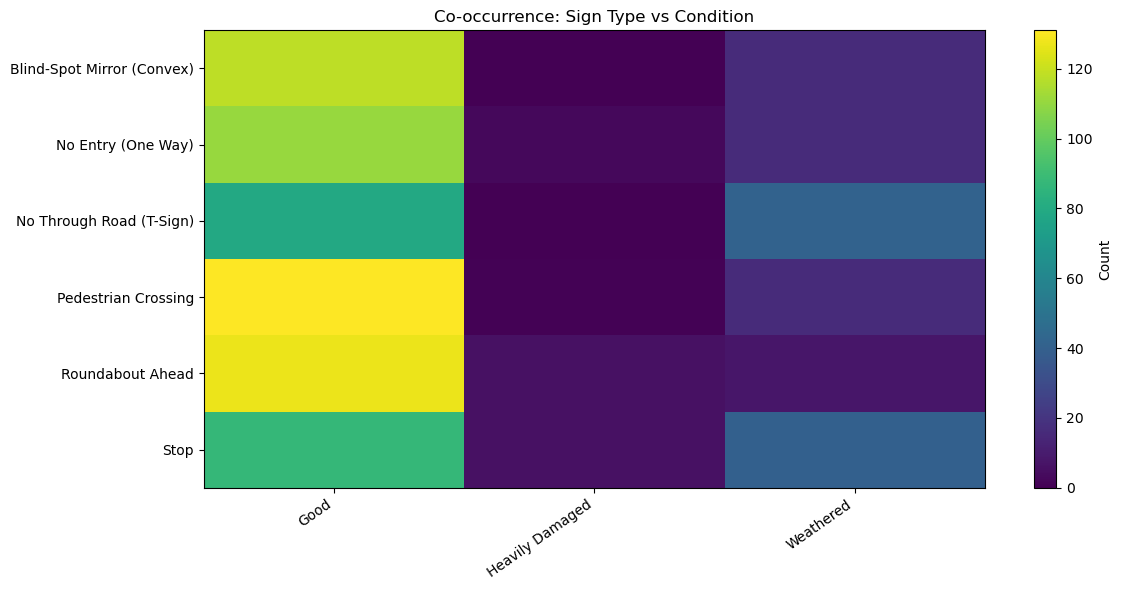

condition,Good,Heavily Damaged,Weathered
category_name,,,
Blind-Spot Mirror (Convex),118,0,16
No Entry (One Way),111,3,16
No Through Road (T-Sign),79,0,41
Pedestrian Crossing,131,1,16
Roundabout Ahead,127,6,8
Stop,87,6,40


In [18]:
def plot_crosstab_heatmap(df, row_col, col_col, title):
    ct = pd.crosstab(df[row_col], df[col_col])

    plt.figure(figsize=(12, 6))
    plt.imshow(ct.values, aspect="auto")
    plt.xticks(range(ct.shape[1]), ct.columns.astype(str), rotation=35, ha="right")
    plt.yticks(range(ct.shape[0]), ct.index.astype(str))
    plt.title(title)
    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()

    return ct

ct2 = plot_crosstab_heatmap(ann_df, "category_name", "condition", "Co-occurrence: Sign Type vs Condition")
display(ct2)
